Etapas obrigatórias:
Carregar a base Varejo.csv com pandas e mostrar: número de registros, colunas e tipos de dados. FEITO

Verificar e reportar ao menos dois problemas básicos: valores nulos por coluna, duplicatas e possíveis inconsistências (ex.: datas inválidas ou categorias vazias).
------------------
RESPOSTA: 3 Colunas vazias, tipo de categoria ND = NULO
------------------

Fazer as três etapas de limpeza mínima necessária: remover ou imputar nulos (explique a escolha), eliminar duplicatas relevantes e ajustar tipos de dados (ex.: converter coluna DATA para datetime).
------------------
RESPOSTA: Realizei a retirada das 3 colunas (Unnamed) e a retirada da categoria ND para não atrapalhar a visualização do grafico de Histograma. troca de DATA para DATATIME foi feita
------------------

Gerar estatísticas descritivas básicas para coluna de número de filhos do cliente (média; mediana; desvio padrão; moda; máximo; mínimo; e contagem).
------------------
Resposta: Total de filhos 1136, 
Media de: 1.14654,
Desvio Padrão: 1.41696,
75%: 2
max: 4
------------------

Explorar padrões de agrupamento com pelo menos dois agrupamentos (por exemplo: gênero com mais vendas, compras), usando groupby() ou pivot_table().
Produzir um pequeno bloco de conclusões (3–6 tópicos) com os principais insights obtidos e possíveis problemas remanescentes na base.

Requisitos técnicos mínimos:
O script deve ser executável em VsCode ou Google Colab (arquivo .py).
Usar pandas; outras bibliotecas são opcionais (NumPy, Matplotlib, Seaborn).


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#---- LEITURA DO ARQUIVO CSV ----
df = pd.read_csv("Base_Varejo.csv", sep=";", encoding="cp1252", decimal=",")
# Converte a coluna de data de admissão para o tipo datetime
df["DATA"] = pd.to_datetime(
    df["DATA"],
    format="%d/%m/%Y",
    errors="coerce"
)


# Remove todas as colunas cujo nome começa com 'Unnamed'
df = df.loc[:, ~df.columns.str.contains('^Unnamed')] 

#---- EXIBIÇÃO DAS 5 PRIMEIRAS LINHAS e 5 ultimas LINHAS DO DATAFRAME ----
df.head(5)
#df.tail(5)

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


In [24]:
print(f"DataFrame possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
print('\n' + '='*50)
print(f"Nomes das Colunas: ")
print(df.columns)
print('\n' + '='*50)
print(f"Tipos de Dados: ")
print(df.dtypes)

DataFrame possui 830000 linhas e 10 colunas.

Nomes das Colunas: 
Index(['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG',
       'PR_ID', 'PR_CAT', 'PR_NOME'],
      dtype='str')

Tipos de Dados: 
DATA         datetime64[us]
CO_ID                 int64
CL_ID                 int64
CL_GENERO               str
CL_EC                 int64
CL_FHL                int64
CL_SEG                  str
PR_ID                 int64
PR_CAT                  str
PR_NOME                 str
dtype: object


In [25]:

# Esta puxando os valores únicos da coluna CL_ID e retirando as duplicatas porque se fizer so com .sum vai contar os filhos de cada compra, e não o total de filhos dos clientes, que é o que queremos.
df_unicos = df.drop_duplicates(subset="CL_ID")

print(f"Total de filhos dos clientes: {df_unicos['CL_FHL'].sum()}")

#Estatisticas descritivas básicas para coluna de número de filhos do cliente (média; mediana; desvio padrão; moda; máximo; mínimo; e contagem).
df["CL_FHL"].describe()




Total de filhos dos clientes: 1136


count    830000.00000
mean          1.14654
std           1.41696
min           0.00000
25%           0.00000
50%           0.00000
75%           2.00000
max           4.00000
Name: CL_FHL, dtype: float64

In [26]:

print(df.info()) # para verificar o número de valores não nulos em cada coluna, e confirmar que estão no formato esperado (ex: sem espaços, sem caracteres estranhos, etc).

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       830000 non-null  datetime64[us]
 1   CO_ID      830000 non-null  int64         
 2   CL_ID      830000 non-null  int64         
 3   CL_GENERO  830000 non-null  str           
 4   CL_EC      830000 non-null  int64         
 5   CL_FHL     830000 non-null  int64         
 6   CL_SEG     830000 non-null  str           
 7   PR_ID      830000 non-null  int64         
 8   PR_CAT     830000 non-null  str           
 9   PR_NOME    830000 non-null  str           
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 63.3 MB
None


In [27]:
print(df.describe()) # para obter uma visão geral das colunas numéricas, incluindo contagem, média, desvio padrão, valores mínimos e máximos, e os quartis.
# nao aparece haver colunas numéricas, então o resultado do describe() é vazio.

                             DATA         CO_ID          CL_ID          CL_EC  \
count                      830000  830000.00000  830000.000000  830000.000000   
mean   2020-12-06 14:55:46.421204  460045.08989     499.595204       2.596911   
min           2019-01-04 00:00:00    1000.00000       1.000000       1.000000   
25%           2020-01-09 00:00:00  233117.00000     254.000000       2.000000   
50%           2020-12-27 00:00:00  456517.00000     498.000000       3.000000   
75%           2021-10-20 00:00:00  690132.00000     746.000000       4.000000   
max           2022-12-08 00:00:00  919822.00000    1000.000000       5.000000   
std                           NaN  265465.24754     287.568253       1.170599   

             CL_FHL          PR_ID  
count  830000.00000  830000.000000  
mean        1.14654     115.051855  
min         0.00000       1.000000  
25%         0.00000      58.000000  
50%         0.00000     115.000000  
75%         2.00000     172.000000  
max        

In [28]:
print('Valores únicos por coluna:')
print(df.nunique())

# para verificar os valores únicos de cada coluna, e confirmar que estão no formato esperado (ex: sem espaços, sem caracteres estranhos, etc).
#df[["DATA","CO_ID","CL_ID","CL_GENERO","CL_EC","CL_FHL","CL_SEG","PR_ID","PR_CAT","PR_NOME"]].head(10) 
df["PR_CAT"].value_counts() # para verificar os valores únicos da coluna "PR_CAT", e confirmar que estão no formato esperado (ex: sem espaços, sem caracteres estranhos, etc).



Valores únicos por coluna:
DATA           333
CO_ID        18471
CL_ID         1000
CL_GENERO        2
CL_EC            5
CL_FHL           5
CL_SEG           3
PR_ID          229
PR_CAT           7
PR_NOME        118
dtype: int64


PR_CAT
ALIMENTOS     434767
HIGIENE       155574
LIMPEZA       145754
BEBIDAS        43299
PET            32399
ACESSORIOS     14557
#N/D            3650
Name: count, dtype: int64

Agora realizar as visualizações


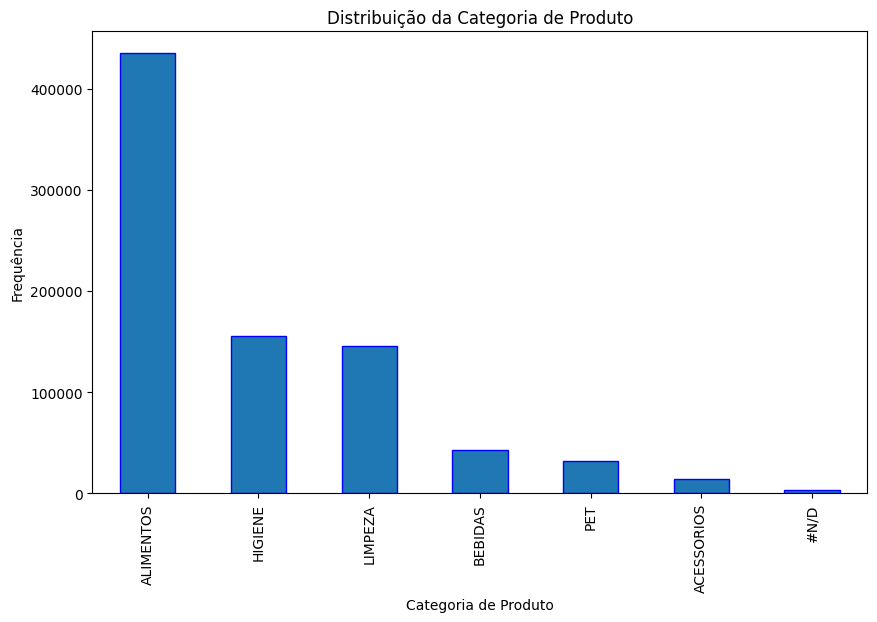

In [29]:
# Contagem das categorias
contagem = df["PR_CAT"].value_counts() # para contar a frequência de cada categoria na coluna "PR_CAT", e obter uma série com os valores únicos e suas respectivas contagens.

# Gráfico de barras
contagem.plot(kind="bar", figsize=(10,6), edgecolor="blue") # para criar um gráfico de barras com as contagens das categorias, e personalizar o tamanho da figura e a cor da borda das barras.
plt.title("Distribuição da Categoria de Produto")# para adicionar um título ao gráfico, e descrever o que ele representa.
plt.xlabel("Categoria de Produto")# para adicionar um rótulo ao eixo x, e descrever o que ele representa.
plt.ylabel("Frequência")# para adicionar um rótulo ao eixo y, e descrever o que ele representa.
plt.show()# para exibir o gráfico, e visualizar a distribuição das categorias de produto.


# DataFrame possui 830000 linhas e 14 colunas.
# 4 Colunas sem nome e sem valores ( consegui remover as colunas)
# 5 colunas Stings, 5 colunas Int, 4 colunas Float (sem nomes)
 clientes = 1000
 categoria de produtos 7 (1cvategoria e ND)
 118 tipos de produtos
 
 # import numpy as np para retirar a categoria ND do meu histograma 